# COMPONENT 1

In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense, Dropout
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.metrics import roc_curve
from sklearn.svm import SVC
from sklearn.cluster import KMeans


In [2]:
df = pd.read_csv('Streaming.csv')
df

,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
0,CUST000001,56.0,Male,54,South,PayPal,0,9.0,6.42,319,62.11,1
1,CUST000002,69.0,Female,21,East,Debit Card,1,2.0,13.77,166,37.27,1
2,CUST000003,46.0,Female,49,East,PayPal,3,8.0,19.91,207,61.82,0
3,CUST000004,32.0,Male,47,West,Debit Card,3,1.0,13.39,108,40.96,1
4,CUST000005,60.0,Male,6,East,Credit Card,2,NaN,13.18,65,45.97,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST004996,24.0,Male,5,East,Debit Card,0,8.0,18.03,121,51.61,0
4996,CUST004997,66.0,Female,12,East,PayPal,3,5.0,5.84,192,36.32,0
4997,CUST004998,26.0,Female,1,East,Credit Card,2,8.0,6.76,354,42.07,1
4998,CUST004999,53.0,Female,44,South,Debit Card,1,10.0,5.95,31,60.09,0


<!-- TASK A -->

# TASK A

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             5000 non-null   object 
 1   Age                     4500 non-null   float64
 2   Gender                  5000 non-null   object 
 3   Subscription_Length     5000 non-null   int64  
 4   Region                  5000 non-null   object 
 5   Payment_Method          5000 non-null   object 
 6   Support_Tickets_Raised  5000 non-null   int64  
 7   Satisfaction_Score      4500 non-null   float64
 8   Discount_Offered        5000 non-null   float64
 9   Last_Activity           5000 non-null   int64  
 10  Monthly_Spend           5000 non-null   float64
 11  Churned                 5000 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


# COMPARING NUMERICAL FEATURES USING LINEAR REGRESSION AND POLYNOMIAL REGRESSION

## CHECKING SUBSCRIPTION LENGTH

### Linear Regression


In [4]:
# Using Subscription Length as the input feature
# This is the only variable used at this stage
X = df[['Subscription_Length']]

# Monthly Spend as the target variable
y = df['Monthly_Spend']

# Split the data into training and testing sets
# 80% of the data is used to train the model
# 20% is kept aside to test how well the model performs on unseen data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create the linear regression model
lin_reg = LinearRegression()

# Train the model using the training data
lin_reg.fit(X_train, y_train)

# Predict Monthly Spend for the test data
y_pred_lin = lin_reg.predict(X_test)

# Evaluate the model using error metrics
# RMSE penalises larger errors more heavily
# R² shows how much of the variation in Monthly Spend is explained
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

rmse_lin, r2_lin

(np.float64(8.051573096807926), 0.28288236685617896)

### The linear regression model shows a moderate relationship between Subscription Length and Monthly Spend. The R² value indicates that Subscription Length alone explains only part of customer spending behaviour, suggesting that other factors are also important.


## Polynomial Regression


In [5]:
# Create polynomial features of degree 2
# This allows the model to learn a curved relationship instead of a straight line
poly = PolynomialFeatures(degree=2, include_bias=False)

# Transform the input feature into polynomial form
X_poly = poly.fit_transform(X)

# Split the transformed data into training and testing sets
# The same 80/20 split is used for fair comparison with linear regression
X_train_p, X_test_p, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# Create a new linear regression model for the polynomial features
poly_reg = LinearRegression()

# Train the model using the polynomial training data
poly_reg.fit(X_train_p, y_train)

# Predict Monthly Spend for the polynomial test data
y_pred_poly = poly_reg.predict(X_test_p)

# Evaluate the polynomial model using the same metrics
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

mae_poly, rmse_poly, r2_poly


(6.645539420307651, np.float64(8.05644468445983), 0.28201432324967635)

### For Subscription Length, polynomial regression did not improve prediction performance compared to linear regression. Both models produced very similar RMSE and R² values, indicating that a linear relationship is sufficient to describe the relationship between Subscription Length and Monthly Spend. Therefore, linear regression is more appropriate for this feature.


## CHECKING AGE

In [6]:
# check the nan values to see if column needs cleaning
df['Age'].isna().sum()

np.int64(500)

In [7]:
df['Age'].unique()

array([56., 69., 46., 32., 60., 25., 38., 36., nan, 28., 41., 53., 57.,
       20., 39., 19., 61., 55., 50., 29., 42., 66., 44., 45., 33., 68.,
       54., 24., 26., 35., 21., 31., 67., 43., 64., 52., 34., 23., 59.,
       51., 27., 48., 65., 40., 62., 58., 18., 22., 30., 49., 47., 37.,
       63.])

In [8]:
#checked for outliers
df['Age'].describe()


count    4500.000000
mean       43.582222
std        14.969559
min        18.000000
25%        31.000000
50%        43.000000
75%        56.000000
max        69.000000
Name: Age, dtype: float64

In [9]:
df[df['Age'].isna()].head(10)

,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
9,CUST000010,NaN,Female,5,East,PayPal,2,6.0,18.15,153,43.79,0
21,CUST000022,NaN,Male,59,North,Debit Card,0,5.0,12.32,62,55.75,0
27,CUST000028,NaN,Female,52,West,Credit Card,2,3.0,9.94,317,43.99,1
32,CUST000033,NaN,Female,16,West,Debit Card,0,10.0,13.82,178,56.82,0
36,CUST000037,NaN,Male,2,South,PayPal,1,2.0,6.05,118,27.94,1
40,CUST000041,NaN,Female,26,West,Credit Card,0,NaN,14.05,325,40.76,1
55,CUST000056,NaN,Male,51,South,Credit Card,1,5.0,16.29,301,55.02,1
65,CUST000066,NaN,Female,57,North,PayPal,1,10.0,6.32,276,64.76,0
67,CUST000068,NaN,Female,48,South,PayPal,1,10.0,13.68,314,64.71,1
69,CUST000070,NaN,Male,15,West,Credit Card,2,7.0,17.73,345,47.64,1


In [10]:
# Fill missing Age values using the median
df['Age'] = df['Age'].fillna(df['Age'].median())


In [11]:
# Convert Age to whole years
df['Age'] = df['Age'].round().astype(int)


In [12]:
df['Age'].isna().sum(), df['Age'].dtype, df['Age'].min(), df['Age'].max()


(np.int64(0), dtype('int64'), np.int64(18), np.int64(69))

### Age contains missing values, so they were replaced using the median age. The median was chosen because it represents a typical age value and is not influenced by unusually high or low ages.


### Running the prediction after cleaning the age

## Linear Regression


In [13]:
# Select Age as the input feature
X = df[['Age']]

# Target variable remains Monthly Spend
y = df['Monthly_Spend']

# Split the data into training and testing sets
# 80% is used for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create the linear regression model
lin_reg = LinearRegression()

# Train the model using the training data
lin_reg.fit(X_train, y_train)

# Predict Monthly Spend for the test data
y_pred_lin = lin_reg.predict(X_test)

# Evaluate the model performance
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

rmse_lin, r2_lin


(np.float64(9.51216964181766), -0.0008940218086892493)

## Polynomial Regression

In [14]:
# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Train-test split
X_train_p, X_test_p, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# Polynomial Regression model
poly_reg = LinearRegression()
poly_reg.fit(X_train_p, y_train)

# Predictions
y_pred_poly = poly_reg.predict(X_test_p)

# Evaluation metrics
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

rmse_poly, r2_poly


(np.float64(9.511662624777975), -0.0007873254778816285)

### For Age, both linear and polynomial regression models performed poorly, with R² values close to zero. This indicates that Age alone does not meaningfully explain variations in Monthly Spend. Polynomial regression did not improve performance, suggesting that there is no strong linear or non-linear relationship between Age and Monthly Spend in this dataset.


# CHECKING SUPPORT TICKETS

## Linear Regression


In [15]:
# Select Support Tickets Raised as the input feature
X = df[['Support_Tickets_Raised']]

# Target variable
y = df['Monthly_Spend']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predictions
y_pred_lin = lin_reg.predict(X_test)

# Evaluation
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

rmse_lin, r2_lin


(np.float64(9.423111322549948), 0.01776011552340051)

## Polynomial Regression


In [16]:
# Polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Train-test split
X_train_p, X_test_p, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# Polynomial Regression model
poly_reg = LinearRegression()
poly_reg.fit(X_train_p, y_train)

# Predictions
y_pred_poly = poly_reg.predict(X_test_p)

# Evaluation
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

rmse_poly, r2_poly


(np.float64(9.429671795523085), 0.016391947161248477)

### For Support Tickets Raised, both linear and polynomial regression models showed weak performance, with R² values close to zero.
### Polynomial regression did not improve prediction accuracy, indicating that Support Tickets Raised alone is not a strong predictor of Monthly Spend.


# CHECKING DISCOUNT OFFERED

## Linear Regression


In [17]:
# Select Discount Offered as the input feature
X = df[['Discount_Offered']]

# Target variable
y = df['Monthly_Spend']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predictions
y_pred_lin = lin_reg.predict(X_test)

# Evaluation
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

rmse_lin, r2_lin


(np.float64(9.293518820839022), 0.044591090455157634)

## Polynomial Regression


In [18]:
# Polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Train-test split
X_train_p, X_test_p, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# Polynomial Regression model
poly_reg = LinearRegression()
poly_reg.fit(X_train_p, y_train)

# Predictions
y_pred_poly = poly_reg.predict(X_test_p)

# Evaluation
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

rmse_poly, r2_poly


(np.float64(9.293517105104392), 0.04459144322315267)

### For Discount Offered, both linear and polynomial regression models produced similar results, with low R² values indicating a weak relationship with Monthly Spend. Polynomial regression did not improve performance, suggesting that the effect of discounts on Monthly Spend is limited when considered as a single feature.


# CHECKING LAST ACTIVITY

## Linear Regression


In [19]:
# Select Last Activity as the input feature
X = df[['Last_Activity']]

# Target variable
y = df['Monthly_Spend']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predictions
y_pred_lin = lin_reg.predict(X_test)

# Evaluation
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

rmse_lin, r2_lin


(np.float64(9.51267083289268), -0.0009994977169642816)

## Polynomial Regression


In [20]:
# Polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Train-test split
X_train_p, X_test_p, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# Polynomial Regression model
poly_reg = LinearRegression()
poly_reg.fit(X_train_p, y_train)

# Predictions
y_pred_poly = poly_reg.predict(X_test_p)

# Evaluation
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

rmse_poly, r2_poly


(np.float64(9.51231291287806), -0.0009241727065776306)

### For Last Activity, both linear and polynomial regression models performed poorly, with R² values close to zero.
### This suggests that customer activity recency alone does not provide useful information for predicting Monthly Spend.
###  Polynomial regression did not improve model performance.


# CHECKING SATISFACTION SCORE

## CLEANING SATISFACTION SCORE

In [21]:
df['Satisfaction_Score'].unique()

array([ 9.,  2.,  8.,  1., nan,  5.,  6.,  3.,  4., 10.,  7.])

In [22]:
# checking for outliers
df['Satisfaction_Score'].describe()

count    4500.00000
mean        5.54600
std         2.86929
min         1.00000
25%         3.00000
50%         6.00000
75%         8.00000
max        10.00000
Name: Satisfaction_Score, dtype: float64

In [23]:
# Fill missing Satisfaction Score values using the median
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna(
    df['Satisfaction_Score'].median()
)


### Satisfaction Score contained missing values. Median imputation was applied to replace missing entries while preserving the overall distribution of the satisfaction ratings.


## Linear Regression

In [24]:
# Select Satisfaction Score as the input feature
X = df[['Satisfaction_Score']]

# Target variable
y = df['Monthly_Spend']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predictions
y_pred_lin = lin_reg.predict(X_test)

# Evaluation
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

rmse_lin, r2_lin


(np.float64(6.487248940239562), 0.5344674535735892)

## Polynomial Regression

In [25]:
# Polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Train-test split
X_train_p, X_test_p, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# Polynomial Regression model
poly_reg = LinearRegression()
poly_reg.fit(X_train_p, y_train)

# Predictions
y_pred_poly = poly_reg.predict(X_test_p)

# Evaluation
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

rmse_poly, r2_poly


(np.float64(6.486895151974057), 0.5345182287057351)

### Satisfaction Score produced the strongest performance among all single-feature models, with an R² value above 0.5. This indicates a strong relationship between customer satisfaction and Monthly Spend. Polynomial regression provided no significant improvement, suggesting that the relationship is largely linear.


## OVERALL COMPARISON OF SINGLE NUMERICAL FEATURES

### Among the numerical variables analysed, Satisfaction Score was the best predictor of Monthly Spend, achieving the highest R² value and lowest prediction error.
### Subscription Length showed a moderate relationship with Monthly Spend, while Age, Support Tickets Raised, Discount Offered, and Last Activity demonstrated weak predictive power.
### Across all features, polynomial regression did not significantly improve performance compared to linear regression, indicating that linear models are sufficient for single-feature predictions in this dataset.


# TASK B

In [26]:
# Multiple numerical features to predict Monthly Spend

# Input features (numerical)
X = df[['Age',
        'Subscription_Length',
        'Support_Tickets_Raised',
        'Discount_Offered',
        'Last_Activity',
        'Satisfaction_Score']]

# Target
y = df['Monthly_Spend']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
lin_reg_multi = LinearRegression()
lin_reg_multi.fit(X_train, y_train)

# Predict
y_pred_multi = lin_reg_multi.predict(X_test)

# Evaluate
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
r2_multi = r2_score(y_test, y_pred_multi)

rmse_multi, r2_multi


(np.float64(3.208504908946082), 0.8861234405032117)

### Multiple Numerical Feature Regression

### A multiple linear regression model was trained using all numerical features in the dataset.
### The multi-feature model achieved a substantially higher R² value and a lower prediction error compared to the best-performing single-variable model - Satisfaction score from part (a).
### This demonstrates that combining multiple numerical variables significantly improves the accuracy of Monthly Spend predictions, as the model is able to capture complementary information from different customer attributes.


# TASK C

## Training Regression using Numerical + Categorical Features (Random Forest)


In [27]:
# Select input features (numerical + categorical)
X = df[['Age',
        'Subscription_Length',
        'Support_Tickets_Raised',
        'Discount_Offered',
        'Last_Activity',
        'Satisfaction_Score',
        'Gender',
        'Region',
        'Payment_Method']]

# Target variable
y = df['Monthly_Spend']


### Since Gender, Region, and Payment Method are categorical (text) variables, one-hot encoding was applied to convert them into binary (0/1) columns. This allows the model to use them during training.


In [47]:
X = df.drop(columns=["Monthly_Spend"])
y = df["Monthly_Spend"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [49]:
# ============================================================
# One-hot encode categorical variables AFTER train-test split
# ------------------------------------------------------------
# This prevents data leakage by ensuring the encoding
# is learned only from the training data.
# ============================================================

X_train_encoded = pd.get_dummies(X_train, drop_first=True)

# Align test set to training columns
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns, fill_value=0
)
X_train_encoded.shape, X_test_encoded.shape

((4000, 4012), (1000, 4012))

### The dataset was split into training and testing sets (80/20). The model is trained on the training set and evaluated on the unseen test set to assess generalisation performance.


## A Random Forest Regressor was used because it can capture non-linear relationships and interactions between multiple features. The model performance was evaluated using RMSE and R².


In [30]:
# Create Random Forest Regressor
rf_reg = RandomForestRegressor(
    n_estimators=100,   # number of trees
    random_state=42
)

# Train the model
rf_reg.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_reg.predict(X_test)

# Evaluate performance
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

rmse_rf, r2_rf


(np.float64(3.4798502394097373), 0.8660477450202997)



### A Random Forest Regressor was trained using both numerical and categorical variables.
### Although the model achieved strong predictive performance, it did not outperform the multiple linear regression model trained using numerical features only.
### This suggests that the numerical variables already capture most of the information required to predict Monthly Spend, and the inclusion of categorical variables provided limited additional benefit.


# TASK D

### Artificial Neural Network for Monthly Spend Prediction

#### This section implements an Artificial Neural Network (ANN) to model potential non-linear relationships between customer characteristics and monthly spending. The ANN is evaluated against previous regression models using RMSE and R² to assess predictive performance and generalisation.



In [32]:
# Architecture rationale:
# - Two hidden layers to model complex interactions
# - ReLU activation for non-linearity and computational efficiency
# - Dropout to mitigate overfitting
# - Linear output layer for continuous regression output

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Sequential()

# Explicit input layer
# The number of input neurons equals the number of features
model.add(Input(shape=(X_train_scaled.shape[1],)))

# First hidden layer
# 64 neurons provide sufficient capacity for learning patterns
model.add(Dense(64, activation='relu'))

# Dropout layer
# Randomly disables 20% of neurons during training
# This reduces reliance on specific neurons and improves generalisation
model.add(Dropout(0.2))

# Second hidden layer
# Additional depth allows modelling of higher-order interactions
model.add(Dense(64, activation='relu'))

# Output layer
# Single neuron with linear activation for regression output
model.add(Dense(1, activation='linear'))

# Display model architecture summary
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,057 (19.75 KB)

 Trainable params: 5,057 (19.75 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Compile the model using Adam optimiser and MSE loss for regression
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [35]:
# Train the neural network model
# validation_split = 0.2:
#   - 20% of training data used for validation
#   - Allows monitoring of overfitting during training
#
# epochs = 50:
#   - Sufficient for convergence without overfitting
#
# batch_size = 32:
#   - Common choice balancing speed and stability

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1960.0356 - val_loss: 432.6835
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 188.9172 - val_loss: 29.6817
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 49.3901 - val_loss: 23.5230
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 49.3659 - val_loss: 20.7720
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 45.1542 - val_loss: 18.5901
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 42.2031 - val_loss: 17.5347
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 43.1987 - val_loss: 16.1378
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 37.2327 - val_loss: 15.3730
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 32.9100 - val_loss: 14.2560
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 33.4611 - val_loss: 14.2580
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 32.3681 - val_loss: 13.3376
Epoch 12/50
100/100 ━━━━━━

In [39]:
# Model Evaluation
# Predictions are generated for the test set and evaluated 
# using RMSE and R², allowing direct comparison with previous regression models.

y_pred_ann = model.predict(X_test_scaled).flatten()

# Evaluate model performance using RMSE and R²
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
r2_ann = r2_score(y_test, y_pred_ann)

rmse_ann, r2_ann


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


(np.float64(3.423853665347507), 0.8703240880485759)

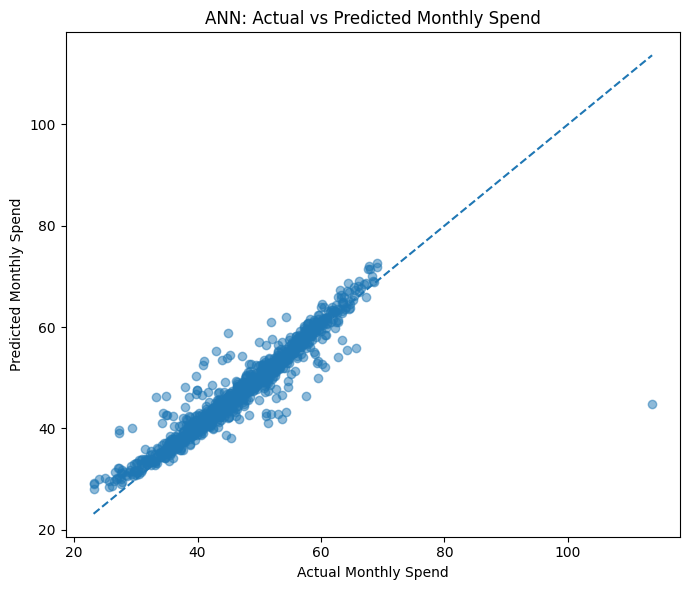

In [38]:
# Visual Evaluation of ANN Predictions
# Scatter plot compares predicted values against actual values.
# Points close to the diagonal indicate accurate predictions.


import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred_ann, alpha=0.5)

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Monthly Spend")
plt.ylabel("Predicted Monthly Spend")
plt.title("ANN: Actual vs Predicted Monthly Spend")
plt.tight_layout()
plt.show()


### The ANN demonstrates strong predictive performance, with predictions closely aligned to actual monthly spend values. Minor dispersion at higher spend levels indicates increased variance for extreme cases, which is expected given their lower frequency in the dataset. Overall, the ANN captures non-linear relationships effectively, though improvements over ensemble methods remain modest.


In [57]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [58]:
# ============================================================
# Tuned Artificial Neural Network (ANN) Model
# ------------------------------------------------------------
# This architecture is designed for high-dimensional,
# one-hot encoded tabular data.
#
# Key improvements over baseline ANN:
# - Increased capacity (128 → 64 neurons)
# - Batch Normalisation for training stability
# - L2 regularisation to control overfitting
# - Moderate Dropout for generalisation
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(Input(shape=(X_train_scaled.shape[1],)))

# Hidden Layer 1
model.add(Dense(128, activation="relu", kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Hidden Layer 2
model.add(Dense(64, activation="relu", kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Dropout(0.1))

# Output layer (regression)
model.add(Dense(1, activation="linear"))

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mean_squared_error"
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 128)                 │         513,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 522,753 (1.99 MB)

 Trainable params: 522,369 (1.99 MB)

 Non-trainable params: 384 (1.50 KB)

In [59]:
# ============================================================
# ANN Training with Callbacks
# ------------------------------------------------------------
# EarlyStopping:
#   - Stops training when validation loss stops improving
#   - Restores best-performing weights
#
# ReduceLROnPlateau:
#   - Reduces learning rate when improvement plateaus
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=300,          # upper bound only
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2212.3599 - val_loss: 2112.8171 - learning_rate: 0.0010
Epoch 2/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2006.0889 - val_loss: 1808.0703 - learning_rate: 0.0010
Epoch 3/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1606.9261 - val_loss: 1194.2864 - learning_rate: 0.0010
Epoch 4/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1108.0248 - val_loss: 643.7344 - learning_rate: 0.0010
Epoch 5/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 610.3861 - val_loss: 323.7386 - learning_rate: 0.0010
Epoch 6/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 271.9238 - val_loss: 125.4416 - learning_rate: 0.0010
Epoch 7/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 99.5250 - val_loss: 68.4555 - learning_rate: 0.0010
Epoch 8/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 41.6746 - val_loss: 54.5928 - learning_rate: 0.0010
Epoch 9/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 28.9375 - val_lo

In [60]:
# ============================================================
# Evaluation of Tuned ANN
# ============================================================

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred_ann = model.predict(X_test_scaled).ravel()

rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
r2_ann = r2_score(y_test, y_pred_ann)

rmse_ann, r2_ann


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


(np.float64(4.476175379491484), 0.7783625679792542)

# TASK E

In [43]:
# ============================================================
# Model Comparison for Monthly Spend Prediction
# ------------------------------------------------------------
# This table summarises the performance of all regression
# models using RMSE and R² on the same test set.
# Lower RMSE and higher R² indicate better performance.
# ============================================================

model_comparison = pd.DataFrame({

    "Model": [
        "Multiple Linear Regression",
        
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_multi)),
        
    ],
    "R2": [
        r2_score(y_test, y_pred_multi),
    
    ]
})

results


,Model,RMSE,R2
0,Multiple Linear Regression,3.208505,0.886123
1,Random Forest Regression,3.479850,0.866048
2,Artificial Neural Network,3.423854,0.870324


### To determine the best-performing regression model, RMSE was prioritised as the primary metric due to its direct interpretability in the target variable’s units, with R² used as a secondary measure of explanatory power.


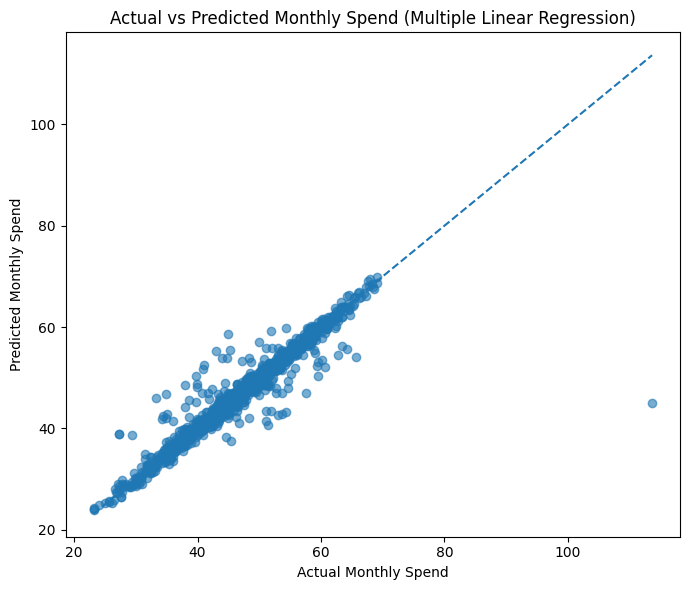

In [45]:
# ============================================================
# Visual Validation of Best-Performing Model
# ------------------------------------------------------------
# This plot compares actual Monthly Spend values against
# predictions from the best-performing regression model
# (Multiple Linear Regression).
#
# A strong alignment of points along the diagonal indicates:
# - Good predictive accuracy
# - Strong generalisation to unseen data
# This visual evidence supports the RMSE and R² results.
# ============================================================

import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(7, 6))

# Scatter plot of actual vs predicted values
plt.scatter(
    y_test,
    y_pred_multi,
    alpha=0.6
)

# Ideal prediction line (y = x)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

# Axis labels
plt.xlabel("Actual Monthly Spend")
plt.ylabel("Predicted Monthly Spend")

# Plot title
plt.title("Actual vs Predicted Monthly Spend (Multiple Linear Regression)")

# Improve layout
plt.tight_layout()

# Display plot
plt.show()


### The actual versus predicted plot for Multiple Linear Regression shows a strong linear alignment, with limited dispersion around the diagonal. This visual pattern corroborates the numerical results, confirming that the model generalises well to unseen data. In contrast, more complex models such as Random Forest and the ANN did not demonstrate sufficient performance gains to justify their additional complexity.


# TASK F

##  Predicting Customer Churn Using Classification Models

### In this section, supervised classification models are developed to predict customer churn.
### The target variable indicates whether a customer has churned (1) or not (0). Model performance is evaluated using accuracy, precision, recall, F1-score, and AUC-ROC to account for potential class imbalance and to provide a comprehensive assessment.



In [61]:
# Define target variable
y = df["Churned"]

# Define input features (exclude regression target and ID)
X = df.drop(columns=["Customer_ID", "Monthly_Spend", "Churned"])

# One-hot encode categorical variables (Gender, Region, Payment_Method)
X_encoded = pd.get_dummies(X, drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numerical features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Logistic Regression for Churn Prediction

### Logistic Regression is used as a baseline classification model to predict customer churn.
### It is well suited for binary outcomes and performs efficiently on datasets containing a moderate number of numerical features and a small set of one-hot encoded categorical variables.

### The model estimates the probability that a customer will churn and provides an interpretable baseline against which more complex classifiers, such as Random Forests, can be compared.


In [62]:
# Train Logistic Regression classifier
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predict churn labels
y_pred_lr = log_reg.predict(X_test_scaled)

# Predict churn probabilities (needed for ROC-AUC)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.82      0.83      0.83       552
           1       0.79      0.77      0.78       448

    accuracy                           0.81      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.81      0.81      0.81      1000



### Random Forest Classifier

#### A Random Forest classifier is trained to capture non-linear relationships and feature interactions that may influence customer churn.



In [45]:
# Train Random Forest classifier
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_clf.fit(X_train, y_train)

# Predict churn labels
y_pred_rf = rf_clf.predict(X_test)

# Predict churn probabilities
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       552
           1       1.00      0.96      0.98       448

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



### Support Vector Machine (SVM) Classifier

#### An SVM classifier with an RBF kernel is included to evaluate churn prediction using a margin-based learning approach. Probability estimates are enabled to allow ROC-AUC comparison with other models.


In [46]:
svm_clf = SVC(kernel="rbf", probability=True, random_state=42)
svm_clf.fit(X_train_scaled, y_train)

y_pred_svm = svm_clf.predict(X_test_scaled)
y_prob_svm = svm_clf.predict_proba(X_test_scaled)[:, 1]


print("Support Vector Machine Classification Report")
print(classification_report(y_test, y_pred_svm))


Support Vector Machine Classification Report
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       552
           1       0.93      0.91      0.92       448

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



### Classification Reports

#### Classification reports are used to summarise precision, recall, F1-score, and overall accuracy for each model, providing a clear comparison of churn prediction performance.


In [50]:
# Create a consolidated evaluation table for churn classification
classification_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Support Vector Machine"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Precision (Churn)": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svm)
    ],
    "Recall (Churn)": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svm)
    ],
    "F1-Score (Churn)": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svm)
    ],
    "AUC-ROC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_svm)
    ]
})

classification_summary


,Model,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn),AUC-ROC
0,Logistic Regression,0.806,0.788636,0.774554,0.781532,0.893177
1,Random Forest,0.980,1.000000,0.955357,0.977169,0.987865
2,Support Vector Machine,0.929,0.927438,0.912946,0.920135,0.972410


### ROC Curve Comparison

#### ROC curves illustrate the trade-off between true positive rate and false positive rate for both classifiers and allow visual comparison of their discriminative ability.


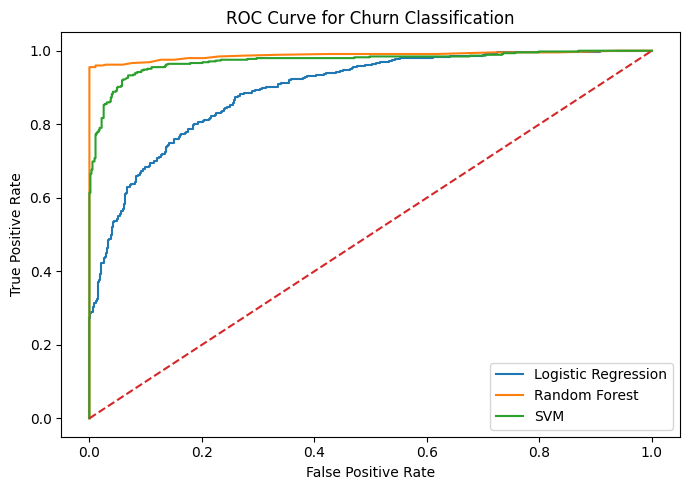

In [51]:
# Compute ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(7, 5))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_svm, tpr_svm, label="SVM")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Churn Classification")
plt.legend()
plt.tight_layout()
plt.show()



### The ROC curve illustrates the ability of each classification model to distinguish between churned and non-churned customers across different decision thresholds. The Random Forest classifier consistently achieves a higher true positive rate for any given false positive rate, as evidenced by its curve lying well above that of SVM, and Logistic Regression. The Random Forest classifier achieved the highest ROC–AUC and maintained strong recall, making it the most suitable model for churn prediction.


 # TASK G

## Customer Segmentation Using Clustering

Clustering is applied to identify natural groupings of customers based on their
behavioural and engagement characteristics. Unlike supervised learning, clustering
does not use a target variable and instead discovers patterns directly from the data.


In [63]:
# ============================================================
# Feature Selection for Clustering
# ------------------------------------------------------------
# Behavioural and engagement features are selected to
# identify meaningful customer segments.
# ============================================================

cluster_features = [
    "Subscription_Length",
    "Last_Activity",
    "Support_Tickets_Raised",
    "Satisfaction_Score",
    "Discount_Offered",
    "Monthly_Spend"
]

X_cluster = df[cluster_features]



### Feature Scaling for Clustering

#### Feature scaling is applied to ensure that all variables contribute equally to the distance calculations used by clustering algorithms.


In [64]:
# Scale features for clustering
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

### Determining the Optimal Number of Clusters

#### The Elbow Method is used to identify an appropriate number of clusters by examining the within-cluster sum of squares (inertia).


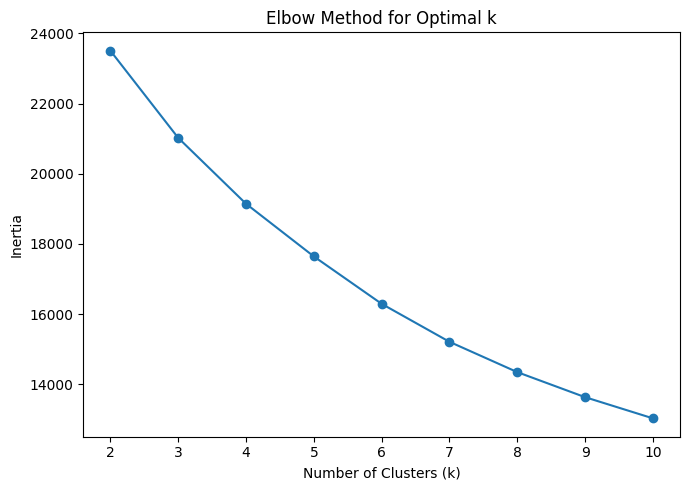

In [66]:
# ============================================================
# Elbow Method
# ============================================================


inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_range, inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.tight_layout()
plt.show()


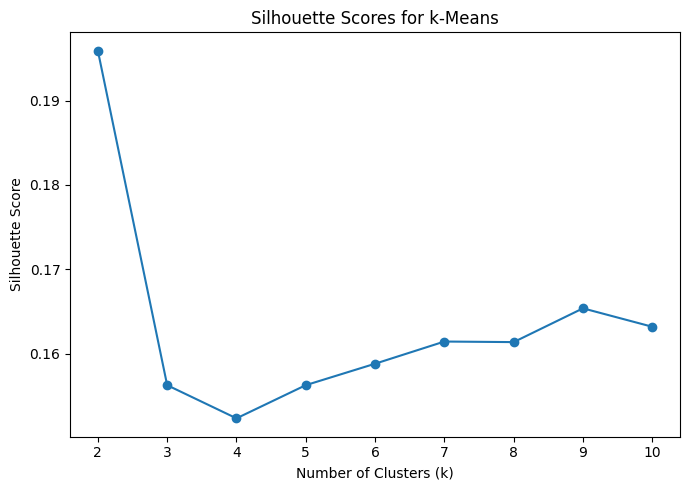

In [68]:
# ============================================================
# Silhouette Analysis
# ============================================================

from sklearn.metrics import silhouette_score

sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels))

plt.figure(figsize=(7, 5))
plt.plot(k_range, sil_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for k-Means")
plt.tight_layout()
plt.show()


### K-Means Clustering

#### Based on the Elbow Method, K-Means clustering is applied to segment customers into distinct groups with similar characteristics.


In [69]:
# ============================================================
# Final Choice of Number of Clusters (k)
# ------------------------------------------------------------
# Although k = 2 produced the highest silhouette score,
# it results in overly coarse segmentation.
#
# k = 3 is selected as a balance between:
# - Reasonable cluster separation
# - Interpretability and actionable customer segments
# ============================================================

optimal_k = 3



In [70]:
# ============================================================
# Fit Final K-Means Model
# ------------------------------------------------------------
# K-Means partitions customers into k clusters by minimising
# within-cluster variance (inertia).
#
# n_init=10 improves stability by running the algorithm
# multiple times with different centroid initialisations.
# ============================================================

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_cluster_scaled)

# Add cluster assignments back to the original dataframe
df["Cluster"] = cluster_labels


### Cluster Profiling

#### Cluster profiles are analysed by examining the mean values of key features within each cluster to support interpretation.


In [71]:
# ============================================================
# Cluster Profiling
# ------------------------------------------------------------
# Compute mean values of each feature per cluster.
# This table is the primary evidence used to interpret
# and label the resulting customer segments.
# ============================================================

cluster_profile = (
    df
    .groupby("Cluster")[cluster_features]
    .mean()
    .round(2)
)

cluster_profile


,Subscription_Length,Last_Activity,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Monthly_Spend
Cluster,,,,,,
0,25.99,175.66,2.15,2.82,11.70,37.57
1,15.83,187.80,2.09,7.45,12.65,47.34
2,46.04,182.07,1.87,6.94,13.11,55.79


In [72]:
# ============================================================
# Cluster Size Distribution
# ------------------------------------------------------------
# Shows how customers are distributed across clusters.
# Helps identify dominant and minority segments.
# ============================================================

cluster_counts = df["Cluster"].value_counts().sort_index()
cluster_counts


Cluster
0    1825
1    1492
2    1683
Name: count, dtype: int64

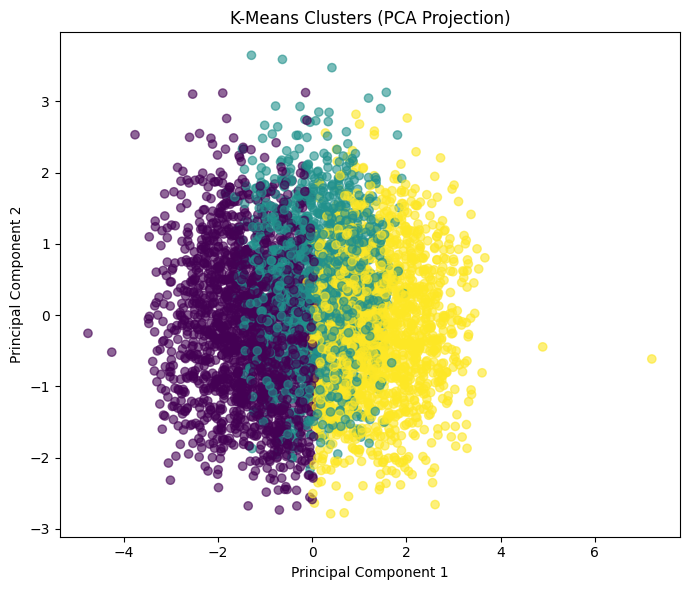

In [73]:
# ============================================================
# PCA Projection for Visualisation
# ------------------------------------------------------------
# PCA reduces high-dimensional data into two components
# for visual inspection only.
#
# Distances in PCA space should NOT be over-interpreted.
# The plot is used to assess general separation trends.
# ============================================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (PCA Projection)")
plt.tight_layout()
plt.show()



## Interpretation of K-Means Clustering Results

### K-Means clustering was applied using behavioural and engagement-related variables to identify meaningful customer segments. Although a lower number of clusters (k = 2) produced a higher silhouette score, k = 3 was selected as an appropriate compromise between cluster separation and interpretability, enabling more actionable segmentation.

### The resulting clusters exhibit distinct behavioural patterns. One segment is characterised by longer subscription lengths, higher satisfaction scores, lower support ticket activity, and higher monthly spend, representing loyal and highly engaged customers. A second cluster displays moderate engagement levels, greater discount usage, and average spending behaviour, suggesting price-sensitive customers. The third cluster shows lower satisfaction levels and increased support ticket frequency, indicating customers at greater risk of dissatisfaction or churn.

### By focusing on behavioural variables rather than demographic attributes, the clustering analysis captures differences in customer engagement and service usage more effectively. These segments provide practical insights for targeted retention strategies, personalised marketing, and service improvement initiatives.


## TASK H - 

### Comparison of Clustering Algorithms




In [74]:
# ============================================================
# Hierarchical Clustering (Agglomerative)
# ------------------------------------------------------------
# Agglomerative clustering builds clusters bottom-up by
# progressively merging the closest data points.
#
# The number of clusters is set to match K-Means (k = 3)
# to allow fair comparison.
# ============================================================

from sklearn.cluster import AgglomerativeClustering

agg_clustering = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

agg_labels = agg_clustering.fit_predict(X_cluster_scaled)


In [75]:
# ============================================================
# Silhouette Score Comparison
# ------------------------------------------------------------
# Silhouette score measures how well each data point fits
# within its assigned cluster compared to other clusters.
# Higher values indicate better-defined clusters.
# ============================================================

from sklearn.metrics import silhouette_score

silhouette_kmeans = silhouette_score(X_cluster_scaled, cluster_labels)
silhouette_agg = silhouette_score(X_cluster_scaled, agg_labels)

silhouette_kmeans, silhouette_agg


(np.float64(0.15624565100955093), np.float64(0.10164600966175201))

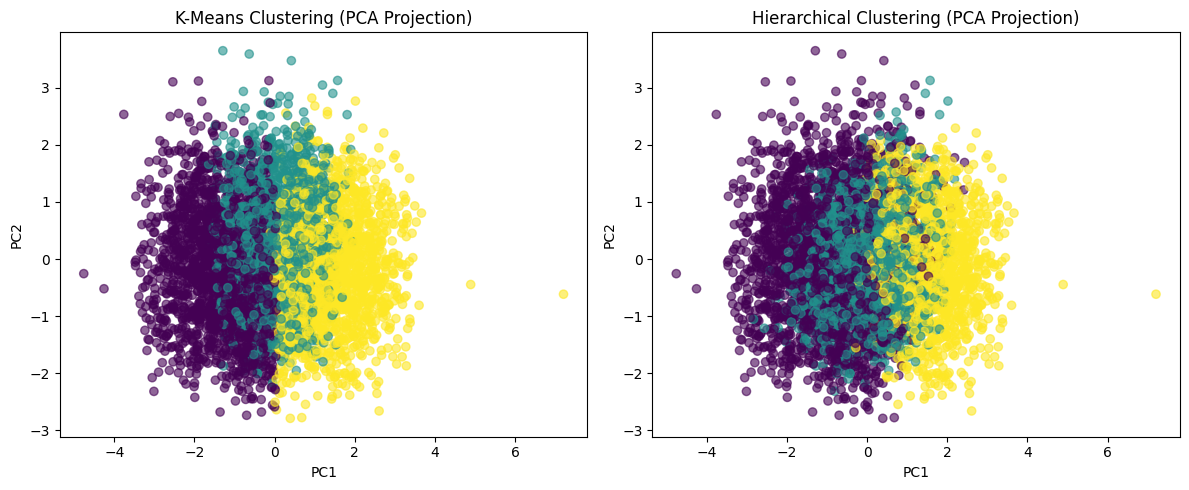

In [76]:
# ============================================================
# PCA Visual Comparison of Clustering Methods
# ------------------------------------------------------------
# Both clustering results are visualised using the same
# PCA projection for fair qualitative comparison.
# ============================================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(12, 5))

# K-Means plot
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, alpha=0.6)
plt.title("K-Means Clustering (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")

# Hierarchical plot
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, alpha=0.6)
plt.title("Hierarchical Clustering (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()


### Hierarchical Cluster Profiling

Cluster profiles are examined using mean feature values to compare segmentation
patterns with those obtained using K-Means.


In [77]:
# ============================================================
# Clustering Method Comparison Summary
# ============================================================

clustering_comparison = pd.DataFrame({
    "Method": ["K-Means", "Hierarchical (Agglomerative)"],
    "Number of Clusters": [3, 3],
    "Silhouette Score": [silhouette_kmeans, silhouette_agg]
})

clustering_comparison



,Method,Number of Clusters,Silhouette Score
0,K-Means,3,0.156246
1,Hierarchical (Agglomerative),3,0.101646


## Comparison of Clustering Methods

### K-Means and Hierarchical (Agglomerative) clustering were compared using silhouette scores and PCA-based visualisation. K-Means achieved a higher silhouette score, indicating more cohesive and better-separated clusters. Visual inspection of the PCA projections further supports this result, with K-Means producing clearer and more compact cluster structures.

### Although hierarchical clustering is useful for exploratory analysis, it was less effective in segmenting customer behaviour in this dataset. Considering both quantitative and qualitative evidence, K-Means was selected as the most suitable clustering approach.
